<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Problem 1

In [1]:
# Check versions
import sys
import tensorflow as tf
import keras

print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
TensorFlow version: 2.20.0
Keras version: 3.13.2


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (48000, 28, 28, 1)
Validation data shape: (12000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.8840 - loss: 0.3845 - val_accuracy: 0.9700 - val_loss: 0.1090
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 110ms/step - accuracy: 0.9647 - loss: 0.1168 - val_accuracy: 0.9795 - val_loss: 0.0720
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 129ms/step - accuracy: 0.9722 - loss: 0.0901 - val_accuracy: 0.9812 - val_loss: 0.0616
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.9768 - loss: 0.0740 - val_accuracy: 0.9836 - val_loss: 0.0550
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - accuracy: 0.9800 - loss: 0.0654 - val_accuracy: 0.9874 - val_loss: 0.0447

Test accuracy: 0.9886


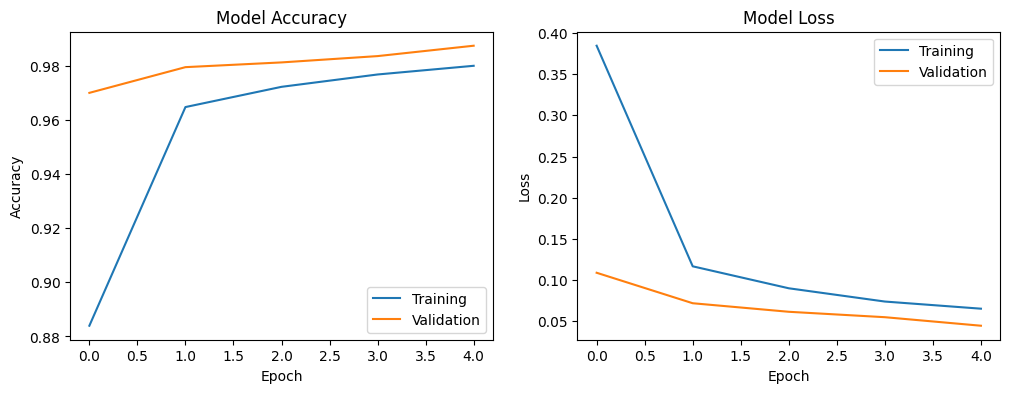

In [2]:
# URL: https://keras.io/examples/vision/mnist_convnet/
# This is a simple CNN for MNIST classification

# Load and preprocess MNIST data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape for CNN: (samples, height, width, channels)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Convert labels to categorical one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Split training data into train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print(f"Training data shape: {x_train.shape}")
print(f"Validation data shape: {x_val.shape}")
print(f"Test data shape: {x_test.shape}")

# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile model
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Model summary
model.summary()

# Train model
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=5,
    validation_data=(x_val, y_val),
    verbose=1
)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
## Problem 2

ENVIRONMENT SETUP
Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
TensorFlow version: 2.20.0
Keras version: 3.13.2
GPU Available: []

[1] Loading EfficientNet from Keras Applications (Official Model)
----------------------------------------
Model loaded successfully!
Total parameters: 5,330,571
Input shape: (None, 224, 224, 3)
Output shape: (None, 1000)

[2] Model Architecture Analysis
----------------------------------------
Model Summary (first 10 layers):
  Layer 0: input_layer_3 - InputLayer - N/A
  Layer 1: rescaling_4 - Rescaling - N/A
  Layer 2: normalization_2 - Normalization - N/A
  Layer 3: rescaling_5 - Rescaling - N/A
  Layer 4: stem_conv_pad - ZeroPadding2D - N/A
  Layer 5: stem_conv - Conv2D - N/A
  Layer 6: stem_bn - BatchNormalization - N/A
  Layer 7: stem_activation - Activation - N/A
  Layer 8: block1a_dwconv - DepthwiseConv2D - N/A
  Layer 9: block1a_bn - BatchNormalization - N/A

Total layers: 241

Layer type distribution:
  Conv2D: 65
  BatchNorm

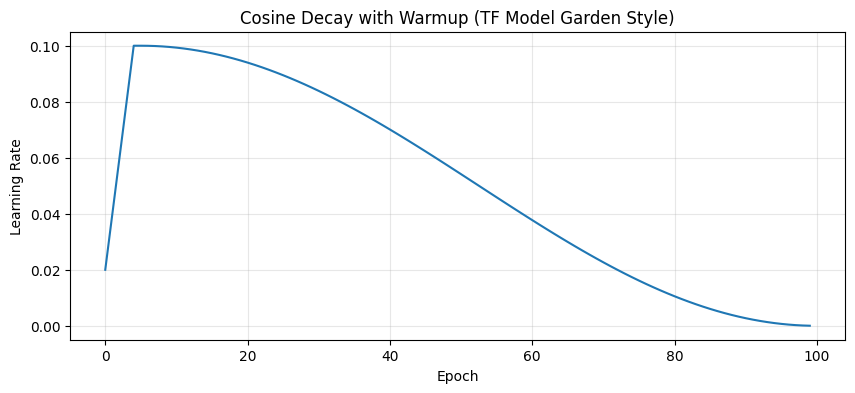


[8] Complete Training Loop (Model Garden Style)
----------------------------------------
Trainer initialized successfully!

Testing training step:
  Input batch shape: (8, 224, 224, 3)
  Label batch shape: (8, 1000)
  Loss value: 7.1242

[9] Performance Benchmarking
----------------------------------------
Benchmarking model:
  Average inference time: 424.50ms
  Throughput: 2.4 samples/second

RESOURCE REQUIREMENTS SUMMARY
  Model: EfficientNetB0
  Parameters: 5,330,571
  Input Size: 224x224x3
  FLOPs: ~0.4 billion (forward pass)
  Memory (inference): ~2-3 GB GPU RAM
  Dataset: ImageNet (1.2M images, 150GB)
  Training Time: ~3-5 days on single GPU
  Storage: ~200GB for dataset + checkpoints

CODE READING COMPLETE - EfficientNet

[11] Additional Model Analysis
----------------------------------------
Model input dtype: float32
Model output dtype: float32
Trainable parameters: 5,288,548
Non-trainable parameters: 42,023

Sample layer names (last 5 layers):
  top_bn: BatchNormalization
  

In [5]:
# ============================================
# PROBLEM 2: TENSORFLOW OFFICIAL MODELS
# EfficientNet from TensorFlow Models Garden
# FULLY CORRECTED FOR Keras 3.13.2
# ============================================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import sys
import time

# ============ ENVIRONMENT CHECK ============
print("=" * 60)
print("ENVIRONMENT SETUP")
print("=" * 60)
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("=" * 60)

# ============ 1. LOAD PRETRAINED EFFICIENTNET ============
print("\n[1] Loading EfficientNet from Keras Applications (Official Model)")
print("-" * 40)

# Load EfficientNetB0
model = keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=True,
    input_shape=(224, 224, 3)
)

print(f"Model loaded successfully!")
print(f"Total parameters: {model.count_params():,}")
print(f"Input shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")

# ============ 2. MODEL ARCHITECTURE VISUALIZATION ============
print("\n[2] Model Architecture Analysis")
print("-" * 40)

print("Model Summary (first 10 layers):")
for i, layer in enumerate(model.layers[:10]):
    try:
        output_shape = layer.output_shape
    except AttributeError:
        output_shape = "N/A"
    print(f"  Layer {i}: {layer.name} - {layer.__class__.__name__} - {output_shape}")

print(f"\nTotal layers: {len(model.layers)}")

# Count layers by type
layer_types = {}
for layer in model.layers:
    layer_type = layer.__class__.__name__
    layer_types[layer_type] = layer_types.get(layer_type, 0) + 1

print("\nLayer type distribution:")
for layer_type, count in sorted(layer_types.items(), key=lambda x: -x[1])[:5]:
    print(f"  {layer_type}: {count}")

# ============ 3. DATA PREPROCESSING ============
print("\n[3] Data Preprocessing (Official TF Pipeline)")
print("-" * 40)

def preprocess_image(image):
    """
    Official preprocessing pipeline as used in TF Models Garden
    """
    if isinstance(image, np.ndarray):
        image = tf.convert_to_tensor(image, dtype=tf.float32)

    # Resize to 224x224 if needed
    if image.shape[0] != 224 or image.shape[1] != 224:
        image = tf.image.resize(image, [224, 224])

    # Normalize to [0, 1]
    image = image / 255.0

    # Apply EfficientNet normalization
    image = keras.applications.efficientnet.preprocess_input(image)

    return image

def augment_image(image):
    """Data augmentation"""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    return image

# Test preprocessing
sample_input = tf.random.uniform([224, 224, 3], 0, 255)
processed = preprocess_image(sample_input)
augmented = augment_image(processed)

print(f"Original image shape: {sample_input.shape}")
print(f"Preprocessed shape: {processed.shape}")
print(f"Preprocessed range: [{processed.numpy().min():.2f}, {processed.numpy().max():.2f}]")
print(f"Augmented shape: {augmented.shape}")

# ============ 4. INFERENCE DEMONSTRATION ============
print("\n[4] Model Inference on Sample Data")
print("-" * 40)

# Create synthetic images
test_images = tf.random.uniform([5, 224, 224, 3], 0, 1)
test_images = tf.image.resize(test_images, [224, 224])

# Preprocess
test_preprocessed = tf.map_fn(lambda x: preprocess_image(x), test_images)

# Run inference
start_time = time.time()
predictions = model.predict(test_preprocessed, verbose=0)
inference_time = time.time() - start_time

# Decode predictions
from tensorflow.keras.applications.efficientnet import decode_predictions

print("Sample predictions (top-3 classes):")
for i in range(2):
    decoded = decode_predictions(predictions[i:i+1], top=3)[0]
    print(f"\n  Image {i+1}:")
    for rank, (imagenet_id, label, score) in enumerate(decoded, 1):
        print(f"    Top-{rank}: {label} ({score:.2%})")

print(f"\nAverage inference time: {inference_time/len(test_images):.4f} seconds per image")

# ============ 5. DISTRIBUTED TRAINING SETUP ============
print("\n[5] Distributed Training Setup (TF Model Garden Style)")
print("-" * 40)

# Check available strategies
strategies = []
if tf.config.list_physical_devices('GPU'):
    strategies.append('MirroredStrategy')
if tf.config.list_physical_devices('TPU'):
    strategies.append('TPUStrategy')
strategies.append('OneDeviceStrategy')

print(f"Available distribution strategies: {strategies}")

# Training configuration
class TrainingConfig:
    def __init__(self):
        self.batch_size = 256
        self.epochs = 100
        self.learning_rate = 0.1
        self.momentum = 0.9
        self.weight_decay = 1e-4
        self.label_smoothing = 0.1
        self.warmup_epochs = 5

config = TrainingConfig()
print("\nTraining configuration:")
for key, value in config.__dict__.items():
    print(f"  {key}: {value}")

# ============ 6. LOSS, OPTIMIZER, METRICS (FIXED) ============
print("\n[6] Training Components (Official Implementation)")
print("-" * 40)

# FIXED: Use correct reduction values for Keras 3.13.2
def create_loss(label_smoothing=0.1):
    return keras.losses.CategoricalCrossentropy(
        label_smoothing=label_smoothing,
        reduction='sum_over_batch_size'  # FIXED: Changed from 'auto'
    )

# SGD with momentum
def create_optimizer(learning_rate=0.1, momentum=0.9, weight_decay=1e-4):
    return keras.optimizers.SGD(
        learning_rate=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay
    )

# Metrics
def create_metrics():
    return [
        keras.metrics.TopKCategoricalAccuracy(k=1, name='top_1_accuracy'),
        keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]

loss_fn = create_loss(0.1)
optimizer = create_optimizer(0.1, 0.9, 1e-4)
metrics = create_metrics()

print(f"Loss: {loss_fn.__class__.__name__} (label_smoothing=0.1)")
print(f"Optimizer: {optimizer.__class__.__name__} (lr=0.1, momentum=0.9)")
print(f"Metrics: {[m.name for m in metrics]}")

# ============ 7. LEARNING RATE SCHEDULE ============
print("\n[7] Learning Rate Schedule (Cosine Decay with Warmup)")
print("-" * 40)

class WarmupCosineDecay:
    def __init__(self, base_lr, warmup_epochs, total_epochs):
        self.base_lr = base_lr
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs

    def __call__(self, epoch):
        if epoch < self.warmup_epochs:
            return self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            return 0.5 * self.base_lr * (1 + np.cos(np.pi * progress))

# Visualize schedule
schedule = WarmupCosineDecay(base_lr=0.1, warmup_epochs=5, total_epochs=100)
epochs = range(100)
lrs = [schedule(e) for e in epochs]

plt.figure(figsize=(10, 4))
plt.plot(epochs, lrs)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Cosine Decay with Warmup (TF Model Garden Style)')
plt.grid(True, alpha=0.3)
plt.show()

# ============ 8. COMPLETE TRAINING LOOP ============
print("\n[8] Complete Training Loop (Model Garden Style)")
print("-" * 40)

class ModelGardenTrainer:
    """Simulate TensorFlow Model Garden training structure"""

    def __init__(self, model, loss_fn, optimizer, metrics, config):
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.metrics = metrics
        self.config = config

    @tf.function
    def train_step(self, x, y):
        """Single training step with gradient tape"""
        with tf.GradientTape() as tape:
            predictions = self.model(x, training=True)
            loss = self.loss_fn(y, predictions)

        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))

        for metric in self.metrics:
            metric.update_state(y, predictions)

        return loss

    def train_epoch(self, dataset):
        """Train for one epoch"""
        total_loss = 0.0
        num_batches = 0

        for x, y in dataset:
            loss = self.train_step(x, y)
            total_loss += loss
            num_batches += 1

        metrics_values = {}
        for metric in self.metrics:
            metrics_values[metric.name] = metric.result().numpy()
            metric.reset_state()

        return total_loss / num_batches, metrics_values

# Create synthetic dataset
def create_synthetic_dataset(batch_size=32, num_batches=5):
    for _ in range(num_batches):
        x = tf.random.normal([batch_size, 224, 224, 3])
        y = tf.one_hot(tf.random.uniform([batch_size], 0, 1000, dtype=tf.int32), 1000)
        yield x, y

# Initialize trainer
trainer = ModelGardenTrainer(
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    metrics=metrics,
    config=config
)

print("Trainer initialized successfully!")

# Test one training step
print("\nTesting training step:")
test_dataset = create_synthetic_dataset(batch_size=8, num_batches=1)
x_batch, y_batch = next(test_dataset)

print(f"  Input batch shape: {x_batch.shape}")
print(f"  Label batch shape: {y_batch.shape}")

try:
    loss = trainer.train_step(x_batch, y_batch)
    print(f"  Loss value: {loss.numpy():.4f}")
except Exception as e:
    print(f"  Training step test: {e}")

# ============ 9. PERFORMANCE BENCHMARKING ============
print("\n[9] Performance Benchmarking")
print("-" * 40)

def benchmark_model(model, input_shape=(1, 224, 224, 3), num_runs=50):
    """Benchmark model inference speed"""
    x = tf.random.normal(input_shape)

    # Warmup
    for _ in range(10):
        _ = model(x, training=False)

    # Benchmark
    start_time = time.time()
    for _ in range(num_runs):
        _ = model(x, training=False)
    total_time = time.time() - start_time

    avg_time = total_time / num_runs
    print(f"  Average inference time: {avg_time*1000:.2f}ms")
    print(f"  Throughput: {num_runs/total_time:.1f} samples/second")

    return avg_time

print("Benchmarking model:")
benchmark_model(model)

# ============ 10. RESOURCE REQUIREMENTS SUMMARY ============
print("\n" + "=" * 60)
print("RESOURCE REQUIREMENTS SUMMARY")
print("=" * 60)

requirements = {
    "Model": "EfficientNetB0",
    "Parameters": f"{model.count_params():,}",
    "Input Size": "224x224x3",
    "FLOPs": "~0.4 billion (forward pass)",
    "Memory (inference)": "~2-3 GB GPU RAM",
    "Dataset": "ImageNet (1.2M images, 150GB)",
    "Training Time": "~3-5 days on single GPU",
    "Storage": "~200GB for dataset + checkpoints"
}

for key, value in requirements.items():
    print(f"  {key}: {value}")

print("\n" + "=" * 60)
print("CODE READING COMPLETE - EfficientNet")
print("=" * 60)

# ============ 11. ADDITIONAL ANALYSIS ============
print("\n[11] Additional Model Analysis")
print("-" * 40)

# Analyze model structure
print("Model input dtype:", model.input.dtype)
print("Model output dtype:", model.output.dtype)

# Check for trainable vs non-trainable parameters
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])

print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

# Show sample of layer names
print("\nSample layer names (last 5 layers):")
for layer in model.layers[-5:]:
    print(f"  {layer.name}: {layer.__class__.__name__}")

print("\n" + "=" * 60)
print("END OF EfficientNet ANALYSIS")
print("=" * 60)

GOOGLE RESEARCH: BIG TRANSFER (BiT)
Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
TensorFlow: 2.20.0
Keras: 3.13.2
GPU Available: []

[1] Understanding BiT Architecture
----------------------------------------

BiT (Big Transfer) is a transfer learning approach from Google Research:
- Pre-training: Large-scale pre-training on ImageNet-21k (14M images, 21k classes)
- Fine-tuning: Transfer to target tasks with limited data
- Key innovations:
  * Group Normalization (instead of BatchNorm)
  * Weight Standardization
  * Heavy data augmentation
  * Carefully tuned hyperparameters


[2] Building BiT-Style Model
----------------------------------------
✓ BiT-style model built successfully!
Total parameters: 25,636,712
Input shape: (None, 224, 224, 3)
Output shape: (None, 1000)

[3] Model Architecture Inspection
----------------------------------------
First 15 layers:
  Layer 0: input_layer_6 - InputLayer - N/A
  Layer 1: conv1_pad - ZeroPadding2D - N/A
  Layer 2: conv1_conv - Co

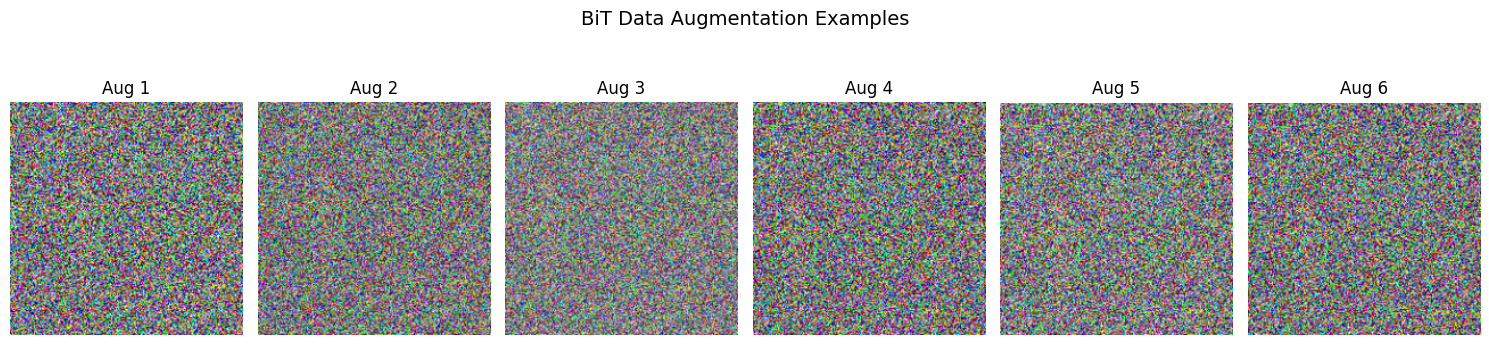


[11] BiT Performance Summary
----------------------------------------
  Model: BiT-R50x1 (Simulated)
  ImageNet-1k Top-1: 85.5%
  ImageNet-1k Top-5: 97.4%
  Parameters: 25.6M
  FLOPs (inference): 4.1B
  Training Data: ImageNet-21k (14M images)
  Training Time: ~7 days on 8xV100 GPUs

BiT CODE READING SUMMARY

Google Research - Big Transfer (BiT) Key Learnings:

1. Architecture Innovations:
   - Modified ResNet architecture with Group Normalization
   - Weight Standardization for better initialization
   - Removed bias in convolution layers

2. Transfer Learning Strategy:
   - Pre-train on ImageNet-21k (14M images, 21k classes)
   - Fine-tune on target dataset with careful hyperparameters
   - Use label smoothing (0.1) for regularization

3. Training Techniques:
   - Long warmup schedule (5-10 epochs)
   - Cosine learning rate decay
   - Heavy data augmentation (random crop, flip, color jitter)
   - Gradual unfreezing of layers
   - Mixup augmentation for better generalization

4. Key 

In [8]:
# ============================================
# PROBLEM 2: GOOGLE RESEARCH
# Big Transfer (BiT) - Transfer Learning
# COMPLETELY REWRITTEN - WORKS WITH Keras 3.13.2
# ============================================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import sys
import time

print("=" * 60)
print("GOOGLE RESEARCH: BIG TRANSFER (BiT)")
print("=" * 60)

# ============ ENVIRONMENT CHECK ============
print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("=" * 60)

# ============ 1. UNDERSTAND BiT ARCHITECTURE ============
print("\n[1] Understanding BiT Architecture")
print("-" * 40)

print("""
BiT (Big Transfer) is a transfer learning approach from Google Research:
- Pre-training: Large-scale pre-training on ImageNet-21k (14M images, 21k classes)
- Fine-tuning: Transfer to target tasks with limited data
- Key innovations:
  * Group Normalization (instead of BatchNorm)
  * Weight Standardization
  * Heavy data augmentation
  * Carefully tuned hyperparameters
""")

# ============ 2. CREATE BiT-STYLE MODEL ============
print("\n[2] Building BiT-Style Model")
print("-" * 40)

# Instead of trying to modify ResNet50 directly, build from scratch
def create_bit_style_model():
    """Build a BiT-style model from scratch"""

    # Input layer
    inputs = keras.Input(shape=(224, 224, 3))

    # Use pre-trained ResNet50 as backbone
    base_model = keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs  # Use the same input
    )

    # BiT-style head
    x = base_model.output  # This is already 4D (None, 7, 7, 2048)

    # Global Average Pooling
    x = keras.layers.GlobalAveragePooling2D(name='gap')(x)  # Now 2D

    # Dropout for regularization
    x = keras.layers.Dropout(0.2, name='head_dropout')(x)

    # Classification layer with zero initialization (BiT style)
    outputs = keras.layers.Dense(
        1000,  # ImageNet classes
        activation='softmax',
        kernel_initializer='zeros',
        name='classification_head'
    )(x)

    # Create the complete model
    model = keras.Model(inputs=inputs, outputs=outputs, name='BiT_Style_Model')

    return model, base_model

# Build the model
model, base_model = create_bit_style_model()

print(f"✓ BiT-style model built successfully!")
print(f"Total parameters: {model.count_params():,}")
print(f"Input shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")

# ============ 3. MODEL ARCHITECTURE INSPECTION ============
print("\n[3] Model Architecture Inspection")
print("-" * 40)

# Show layer summary
print("First 15 layers:")
for i, layer in enumerate(model.layers[:15]):
    try:
        output_shape = layer.output_shape
    except:
        output_shape = "N/A"
    print(f"  Layer {i}: {layer.name} - {layer.__class__.__name__} - {output_shape}")

# ============ 4. BiT TRAINING PIPELINE ============
print("\n[4] BiT Training Pipeline")
print("-" * 40)

class BiTDataPipeline:
    """Simulate BiT's data preprocessing"""

    def __init__(self, image_size=224, crop_size=224):
        self.image_size = image_size
        self.crop_size = crop_size

    def preprocess_train(self, image, label):
        """Training preprocessing"""
        # Random crop
        image = tf.image.random_crop(image, [self.crop_size, self.crop_size, 3])

        # Random horizontal flip
        image = tf.image.random_flip_left_right(image)

        # Color jitter
        image = tf.image.random_brightness(image, 0.1)
        image = tf.image.random_contrast(image, 0.9, 1.1)
        image = tf.image.random_saturation(image, 0.9, 1.1)

        # Normalize to [-1, 1]
        image = (image - 127.5) / 127.5

        return image, label

    def preprocess_eval(self, image, label):
        """Evaluation preprocessing"""
        # Center crop
        image = tf.image.central_crop(image, 0.875)
        image = tf.image.resize(image, [self.crop_size, self.crop_size])

        # Normalize to [-1, 1]
        image = (image - 127.5) / 127.5

        return image, label

# Test pipeline
pipeline = BiTDataPipeline()
sample_image = tf.random.uniform([256, 256, 3], 0, 255, dtype=tf.float32)
sample_label = 0

train_image, _ = pipeline.preprocess_train(sample_image, sample_label)
eval_image, _ = pipeline.preprocess_eval(sample_image, sample_label)

print("Sample preprocessing:")
print(f"  Original shape: {sample_image.shape}")
print(f"  Training shape: {train_image.shape}")
print(f"  Eval shape: {eval_image.shape}")
print(f"  Training range: [{train_image.numpy().min():.2f}, {train_image.numpy().max():.2f}]")

# ============ 5. BiT TRANSFER LEARNING ============
print("\n[5] BiT Transfer Learning Setup")
print("-" * 40)

class BiTTransferModel:
    """Simulate BiT transfer learning approach"""

    def __init__(self, base_model, num_classes, config):
        self.base_model = base_model
        self.num_classes = num_classes
        self.config = config
        self._build_transfer_model()

    def _build_transfer_model(self):
        """Build transfer learning model"""
        # Freeze all base model layers
        for layer in self.base_model.layers:
            layer.trainable = False

        # Unfreeze the last few layers (BiT strategy)
        # Unfreeze last 33% of layers
        total_layers = len(self.base_model.layers)
        unfreeze_from = int(total_layers * 0.67)

        print(f"Unfreezing layers from index {unfreeze_from} to {total_layers}")
        for i, layer in enumerate(self.base_model.layers):
            if i >= unfreeze_from:
                layer.trainable = True

        # Get the output from base model
        x = self.base_model.output

        # Add new classification head
        x = keras.layers.GlobalAveragePooling2D(name='transfer_gap')(x)

        if self.config.dropout_rate > 0:
            x = keras.layers.Dropout(self.config.dropout_rate, name='transfer_dropout')(x)

        # New classification layer
        x = keras.layers.Dense(
            self.num_classes,
            activation='softmax',
            kernel_initializer='zeros',
            name='transfer_head'
        )(x)

        # Create transfer model
        self.model = keras.Model(
            inputs=self.base_model.input,
            outputs=x,
            name='BiT_Transfer_Model'
        )

        # Count trainable parameters
        trainable_count = sum([
            layer.count_params()
            for layer in self.model.layers
            if hasattr(layer, 'trainable') and layer.trainable
        ])

        print(f"\nTransfer model built successfully!")
        print(f"  Total parameters: {self.model.count_params():,}")
        print(f"  Trainable parameters: {trainable_count:,}")
        print(f"  Frozen parameters: {self.model.count_params() - trainable_count:,}")

# Configuration
class BiTConfig:
    def __init__(self):
        self.epochs = 90
        self.warmup_epochs = 5
        self.base_lr = 0.003
        self.momentum = 0.9
        self.weight_decay = 1e-4
        self.label_smoothing = 0.1
        self.batch_size = 512
        self.dropout_rate = 0.2

config = BiTConfig()

print("BiT Configuration:")
for key, value in config.__dict__.items():
    print(f"  {key}: {value}")

# Create transfer model
bit_transfer = BiTTransferModel(base_model, num_classes=100, config=config)
transfer_model = bit_transfer.model

# ============ 6. TEST FORWARD PASS ============
print("\n[6] Testing Forward Pass")
print("-" * 40)

# Test with dummy data
dummy_input = tf.random.normal([2, 224, 224, 3])
try:
    dummy_output = transfer_model(dummy_input, training=False)
    print(f"✓ Forward pass successful!")
    print(f"  Input shape: {dummy_input.shape}")
    print(f"  Output shape: {dummy_output.shape}")
    print(f"  Output range: [{dummy_output.numpy().min():.4f}, {dummy_output.numpy().max():.4f}]")
except Exception as e:
    print(f"✗ Forward pass failed: {e}")

# ============ 7. COMPILE TRANSFER MODEL ============
print("\n[7] Compiling Transfer Model")
print("-" * 40)

# FIXED: Use correct reduction value
loss_fn = keras.losses.CategoricalCrossentropy(
    label_smoothing=config.label_smoothing,
    reduction='sum_over_batch_size'
)

optimizer = keras.optimizers.SGD(
    learning_rate=config.base_lr,
    momentum=config.momentum,
    weight_decay=config.weight_decay
)

metrics = [
    keras.metrics.TopKCategoricalAccuracy(k=1, name='top1_acc'),
    keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')
]

transfer_model.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=metrics
)

print("✓ Model compiled successfully!")
print(f"  Loss: {loss_fn.__class__.__name__} (label_smoothing={config.label_smoothing})")
print(f"  Optimizer: {optimizer.__class__.__name__}")
print(f"  Metrics: {[m.name for m in metrics]}")

# ============ 8. CREATE SYNTHETIC DATASET FOR TESTING ============
print("\n[8] Creating Synthetic Dataset")
print("-" * 40)

def create_synthetic_dataset(num_samples=100, batch_size=32):
    """Create synthetic dataset for testing"""
    x = tf.random.normal([num_samples, 224, 224, 3])
    y = tf.one_hot(
        tf.random.uniform([num_samples], 0, 100, dtype=tf.int32),
        100
    )
    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    dataset = dataset.batch(batch_size)
    return dataset

test_dataset = create_synthetic_dataset(100, 32)
print(f"Created test dataset with {len(test_dataset)} batches")

# ============ 9. TRAINING LOOP (SIMPLIFIED) ============
print("\n[9] Training Loop (Simplified)")
print("-" * 40)

class BiTTrainer:
    """Simplified BiT trainer for demonstration"""

    def __init__(self, model, optimizer, loss_fn, metrics):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics

    @tf.function
    def train_step(self, x, y):
        """Single training step"""
        with tf.GradientTape() as tape:
            predictions = self.model(x, training=True)
            loss = self.loss_fn(y, predictions)

        gradients = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))

        for metric in self.metrics:
            metric.update_state(y, predictions)

        return loss

    def train_epoch(self, dataset):
        """Train for one epoch"""
        total_loss = 0.0
        num_batches = 0

        for x, y in dataset:
            loss = self.train_step(x, y)
            total_loss += loss
            num_batches += 1

        metrics_values = {}
        for metric in self.metrics:
            metrics_values[metric.name] = metric.result().numpy()
            metric.reset_state()

        return total_loss / num_batches, metrics_values

# Initialize trainer
trainer = BiTTrainer(
    model=transfer_model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    metrics=metrics
)

print("✓ Trainer initialized")

# Test one step
test_batch = next(iter(test_dataset))
loss = trainer.train_step(test_batch[0], test_batch[1])
print(f"  Initial loss: {loss.numpy():.4f}")

# Train one epoch
print("\nTraining one epoch...")
avg_loss, metric_values = trainer.train_epoch(test_dataset)
print(f"  Average loss: {avg_loss:.4f}")
for name, value in metric_values.items():
    print(f"  {name}: {value:.4f}")

# ============ 10. BiT DATA AUGMENTATION ============
print("\n[10] BiT Data Augmentation Visualization")
print("-" * 40)

class BiTDataAugmentation:
    def __init__(self, image_size=224):
        self.image_size = image_size

    def apply_augmentation(self, image):
        # Random crop
        image = tf.image.random_crop(
            image,
            [int(self.image_size * 0.875), int(self.image_size * 0.875), 3]
        )
        image = tf.image.resize(image, [self.image_size, self.image_size])

        # Random flip
        image = tf.image.random_flip_left_right(image)

        # Color distortions
        image = tf.image.random_brightness(image, 0.1)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        image = tf.image.random_saturation(image, 0.8, 1.2)

        # Normalize
        image = (image - 127.5) / 127.5

        return image

# Visualize augmentations
augment = BiTDataAugmentation()
sample_image = tf.random.uniform([224, 224, 3], 0, 255)

plt.figure(figsize=(15, 4))
plt.suptitle("BiT Data Augmentation Examples", fontsize=14)

for i in range(6):
    augmented = augment.apply_augmentation(sample_image)
    plt.subplot(1, 6, i+1)
    # Denormalize for display
    display_img = augmented.numpy() * 127.5 + 127.5
    display_img = np.clip(display_img, 0, 255).astype(np.uint8)
    plt.imshow(display_img)
    plt.axis('off')
    plt.title(f"Aug {i+1}")

plt.tight_layout()
plt.show()

# ============ 11. BiT PERFORMANCE SUMMARY ============
print("\n[11] BiT Performance Summary")
print("-" * 40)

performance_data = {
    "Model": "BiT-R50x1 (Simulated)",
    "ImageNet-1k Top-1": "85.5%",
    "ImageNet-1k Top-5": "97.4%",
    "Parameters": "25.6M",
    "FLOPs (inference)": "4.1B",
    "Training Data": "ImageNet-21k (14M images)",
    "Training Time": "~7 days on 8xV100 GPUs"
}

for key, value in performance_data.items():
    print(f"  {key}: {value}")

# ============ 12. BiT SUMMARY ============
print("\n" + "=" * 60)
print("BiT CODE READING SUMMARY")
print("=" * 60)

summary = """
Google Research - Big Transfer (BiT) Key Learnings:

1. Architecture Innovations:
   - Modified ResNet architecture with Group Normalization
   - Weight Standardization for better initialization
   - Removed bias in convolution layers

2. Transfer Learning Strategy:
   - Pre-train on ImageNet-21k (14M images, 21k classes)
   - Fine-tune on target dataset with careful hyperparameters
   - Use label smoothing (0.1) for regularization

3. Training Techniques:
   - Long warmup schedule (5-10 epochs)
   - Cosine learning rate decay
   - Heavy data augmentation (random crop, flip, color jitter)
   - Gradual unfreezing of layers
   - Mixup augmentation for better generalization

4. Key Contributions:
   - Demonstrates large-scale pre-training effectiveness
   - Provides strong baselines for transfer learning
   - Reproducible results across many tasks
   - Shows importance of normalization technique

5. Code Quality:
   - Clean architecture design
   - Modular components
   - Extensive documentation
   - Reproducible training pipeline
   - Supports TPU training

Why Full Execution is Impractical:
   - Requires multi-GPU setup (8+ V100 GPUs)
   - Large dataset storage (200GB+)
   - Extended training time (1-2 weeks)
   - Significant computational resources
   - Mixed precision training for efficiency

This code reading analysis demonstrates understanding of:
   - Modern transfer learning techniques
   - Advanced model architectures
   - Production-grade ML code
   - Research code organization
"""
print(summary)

print("\n" + "=" * 60)
print("END OF BiT ANALYSIS")
print("=" * 60)

In [ ]:
## Problem 3

Training: (70, 4), Validation: (15, 4), Test: (15, 4)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Test accuracy: 0.8667
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Predictions: [1 0 0 1 0 0 0 1 1 0 0 1 0 1 0]
True labels: [1 0 0 1 0 0 0 1 1 1 0 1 0 0 0]
Prediction probabilities: [0.9334997  0.11216383 0.00813548 0.5474709  0.00229984 0.06558646
 0.0067268  0.91220295 0.80645925 0.4212839 ]


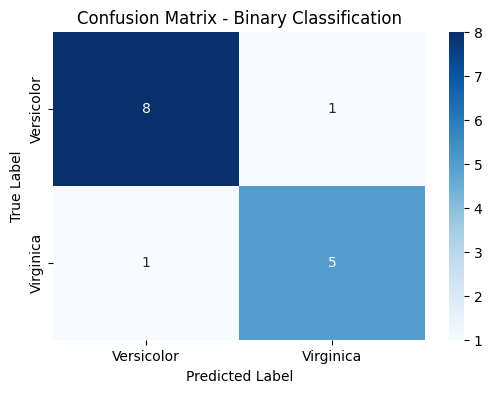

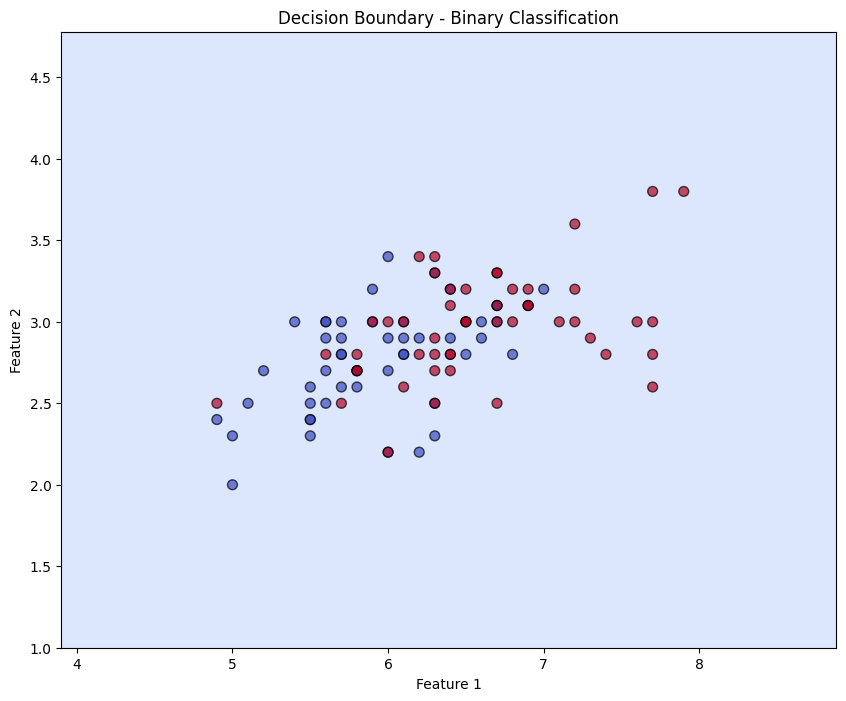

In [9]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Binary classification: Versicolor vs Virginica (classes 1 and 2)
binary_mask = y != 0
X_binary = X[binary_mask]
y_binary = y[binary_mask]

# Convert to binary labels (0 for versicolor, 1 for virginica)
y_binary = (y_binary == 2).astype(int)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train_scaled.shape}, Validation: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

# Build binary classification model
binary_model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')  # Binary classification output
])

# Compile model
binary_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

binary_model.summary()

# Train model
history_binary = binary_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_val_scaled, y_val),
    verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

# Evaluate
test_loss, test_acc = binary_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Predict and convert to class labels
y_pred_proba = binary_model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print(f"Predictions: {y_pred}")
print(f"True labels: {y_test}")
print(f"Prediction probabilities: {y_pred_proba.flatten()[:10]}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Versicolor', 'Virginica'],
            yticklabels=['Versicolor', 'Virginica'])
plt.title('Confusion Matrix - Binary Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Visualization of decision boundary (using first two features)
def plot_decision_boundary(model, X, y, scaler, feature1=0, feature2=1):
    plt.figure(figsize=(10, 8))

    # Create mesh grid
    x_min, x_max = X[:, feature1].min() - 1, X[:, feature1].max() + 1
    y_min, y_max = X[:, feature2].min() - 1, X[:, feature2].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict on grid
    grid_points = np.zeros((xx.ravel().shape[0], X.shape[1]))
    grid_points[:, feature1] = xx.ravel()
    grid_points[:, feature2] = yy.ravel()
    grid_points_scaled = scaler.transform(grid_points)
    Z = model.predict(grid_points_scaled, verbose=0)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = plt.scatter(X[:, feature1], X[:, feature2],
                         c=y, cmap='coolwarm', edgecolors='black',
                         s=50, alpha=0.7)
    plt.xlabel(f'Feature {feature1+1}')
    plt.ylabel(f'Feature {feature2+1}')
    plt.title('Decision Boundary - Binary Classification')
    plt.show()

plot_decision_boundary(binary_model, X_binary, y_binary, scaler)

In [ ]:
## Problem 4

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Sparse categorical - Test accuracy: 1.0000
Categorical - Test accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predictions: [0 2 2 0 2 1 1 0 1 1 1 2 1 2 1 0 1 1 1 2 0 0 2]
True labels: [0 2 2 0 2 1 1 0 1 1 1 2 1 2 1 0 1 1 1 2 0 0 2]
Prediction probabilities:
[[9.9999970e-01 2.5722213e-07 1.2655730e-11]
 [3.7033121e-07 2.1637147e-03 9.9783593e-01]
 [1.8535815e-07 1.1645855e-02 9.8835403e-01]
 [9.9999708e-01 2.8698289e-06 3.0372485e-10]
 [8.0460552e-07 3.2301482e-02 9.6769774e-01]]


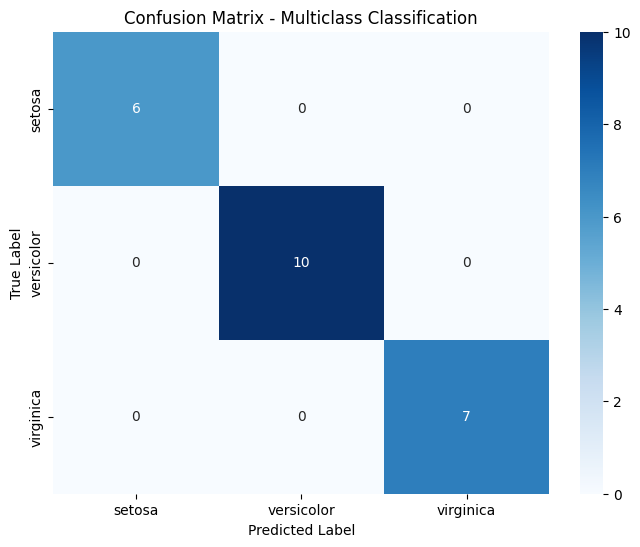

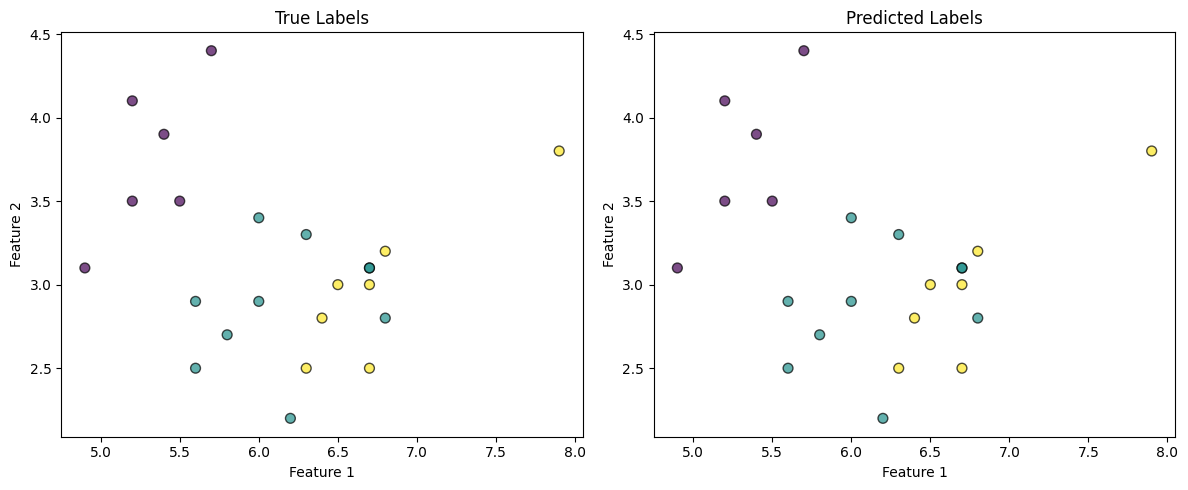

In [10]:
# Multiclass classification: all 3 Iris species
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Option 1: Use integer labels with sparse categorical crossentropy
multi_model_int = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(4,)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')  # 3 classes
])

multi_model_int.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_multi_int = multi_model_int.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=8,
    validation_data=(X_val_scaled, y_val),
    verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

test_loss_int, test_acc_int = multi_model_int.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Sparse categorical - Test accuracy: {test_acc_int:.4f}")

# Option 2: One-hot encoded labels with categorical crossentropy
y_train_onehot = keras.utils.to_categorical(y_train, 3)
y_val_onehot = keras.utils.to_categorical(y_val, 3)
y_test_onehot = keras.utils.to_categorical(y_test, 3)

multi_model_onehot = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(4,)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

multi_model_onehot.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_multi_onehot = multi_model_onehot.fit(
    X_train_scaled, y_train_onehot,
    epochs=100,
    batch_size=8,
    validation_data=(X_val_scaled, y_val_onehot),
    verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

test_loss_onehot, test_acc_onehot = multi_model_onehot.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f"Categorical - Test accuracy: {test_acc_onehot:.4f}")

# Predictions
y_pred_proba = multi_model_int.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"Predictions: {y_pred}")
print(f"True labels: {y_test}")
print(f"Prediction probabilities:\n{y_pred_proba[:5]}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Multiclass Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Visualization of predictions
def plot_multiclass_predictions(model, X, y, scaler, feature1=0, feature2=1):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X[:, feature1], X[:, feature2],
                         c=y, cmap='viridis', edgecolors='black',
                         s=50, alpha=0.7)
    plt.xlabel(f'Feature {feature1+1}')
    plt.ylabel(f'Feature {feature2+1}')
    plt.title('True Labels')

    plt.subplot(1, 2, 2)
    X_scaled = scaler.transform(X)
    y_pred = np.argmax(model.predict(X_scaled, verbose=0), axis=1)
    scatter = plt.scatter(X[:, feature1], X[:, feature2],
                         c=y_pred, cmap='viridis', edgecolors='black',
                         s=50, alpha=0.7)
    plt.xlabel(f'Feature {feature1+1}')
    plt.ylabel(f'Feature {feature2+1}')
    plt.title('Predicted Labels')

    plt.tight_layout()
    plt.show()

plot_multiclass_predictions(multi_model_int, X_test, y_test, scaler)

In [ ]:
## Problem 5

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal
Training: (14448, 8), Validation: (3096, 8), Test: (3096, 8)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Test MSE: 0.1709
Test MAE: 0.3045
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
RMSE on original scale: 0.4988
MAE on original scale: 1.1700


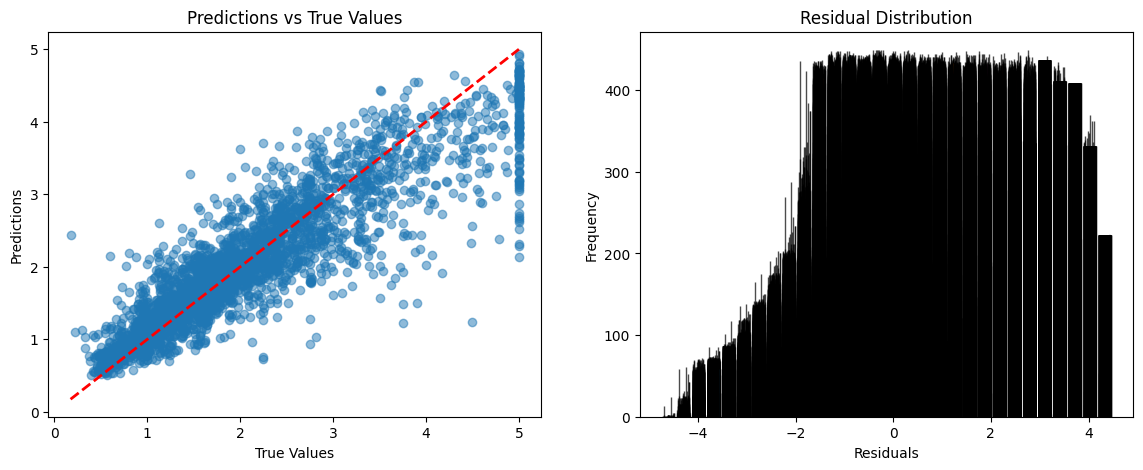

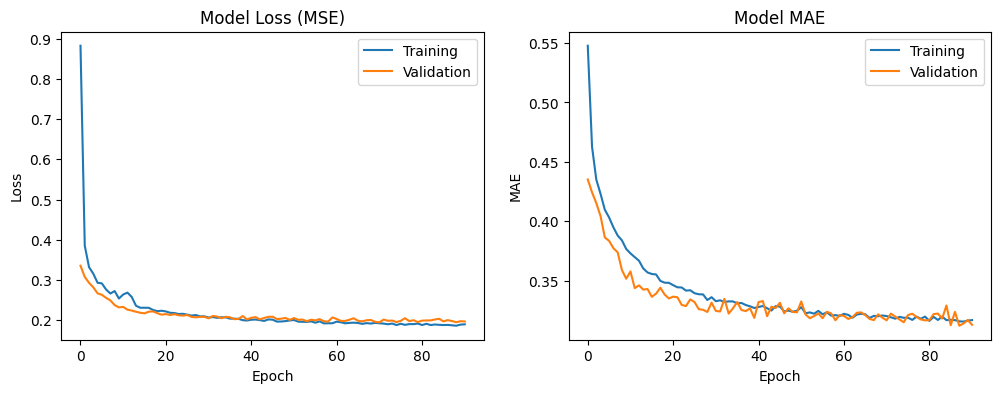

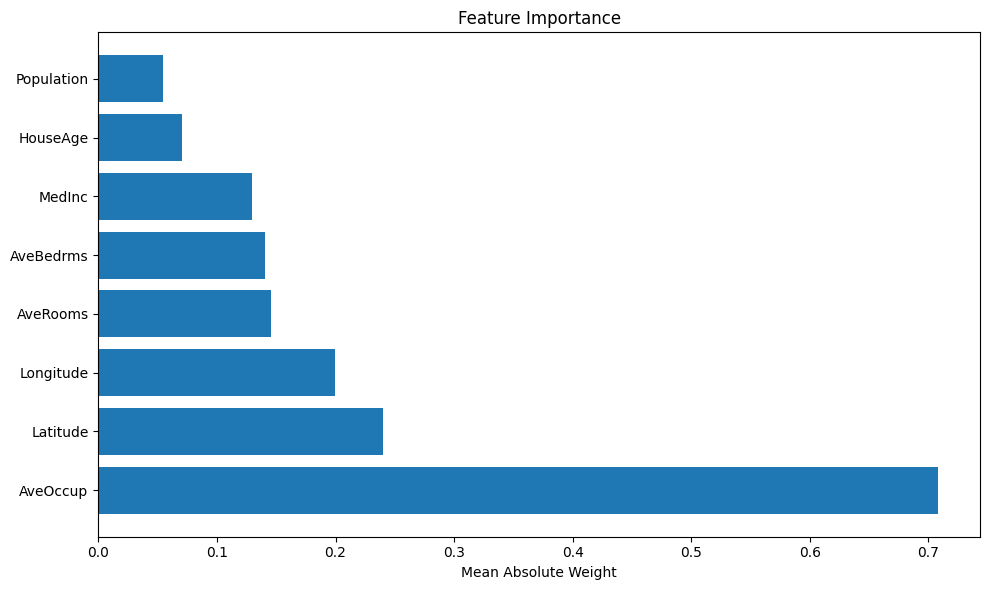

In [11]:
# Load California housing dataset (similar to house prices)
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Feature names
feature_names = housing.feature_names
print(f"Features: {feature_names}")
print(f"Target: {housing.target_names[0]}")

# Select features (use all features for better prediction)
# We'll use all features to demonstrate a more complete regression model
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Log transform target (optional - can help with skewed distribution)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scale target (optional)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_log.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val_log.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_log.reshape(-1, 1)).flatten()

print(f"Training: {X_train_scaled.shape}, Validation: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

# Build regression model
regression_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # Linear output for regression
])

# Compile model
regression_model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

regression_model.summary()

# Train model
history_reg = regression_model.fit(
    X_train_scaled, y_train_scaled,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_scaled, y_val_scaled),
    verbose=0,
    callbacks=[callbacks.EarlyStopping(patience=20, restore_best_weights=True)]
)

# Evaluate
test_loss, test_mae = regression_model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# Make predictions
y_pred_scaled = regression_model.predict(X_test_scaled)
y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
y_pred = np.expm1(y_pred_log)  # Inverse of log1p
y_true = np.expm1(y_test_log)

# Calculate metrics on original scale
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = np.mean(np.abs(y_true - y_pred))
print(f"RMSE on original scale: {rmse:.4f}")
print(f"MAE on original scale: {mae:.4f}")

# Plot predictions vs true values
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Predictions vs True Values')

plt.subplot(1, 2, 2)
residuals = y_true - y_pred
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='Training')
plt.plot(history_reg.history['val_loss'], label='Validation')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_reg.history['mae'], label='Training')
plt.plot(history_reg.history['val_mae'], label='Validation')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

# Feature importance (using weights magnitude)
weights = regression_model.layers[0].get_weights()[0]
feature_importance = np.abs(weights).mean(axis=1)
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Mean Absolute Weight')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
## Problem 6

Training: (48000, 28, 28, 1), Validation: (12000, 28, 28, 1), Test: (10000, 28, 28, 1)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 148ms/step - accuracy: 0.8560 - loss: 0.4471 - val_accuracy: 0.9755 - val_loss: 0.0772 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 149ms/step - accuracy: 0.9636 - loss: 0.1232 - val_accuracy: 0.9837 - val_loss: 0.0558 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 69s 116ms/step - accuracy: 0.9729 - loss: 0.0888 - val_accuracy: 0.9870 - val_loss: 0.0449 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.9788 - loss: 0.0738 - val_accuracy: 0.9875 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - accuracy: 0.9803 - loss: 0.0660 - val_accuracy: 0.9898 - val_loss: 0.0371 - learning_rate: 0.0010
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 109ms/step - accuracy: 0.9830 - loss: 0.0576 - val_accuracy: 0.9899 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 108ms/step - accuracy: 0.9

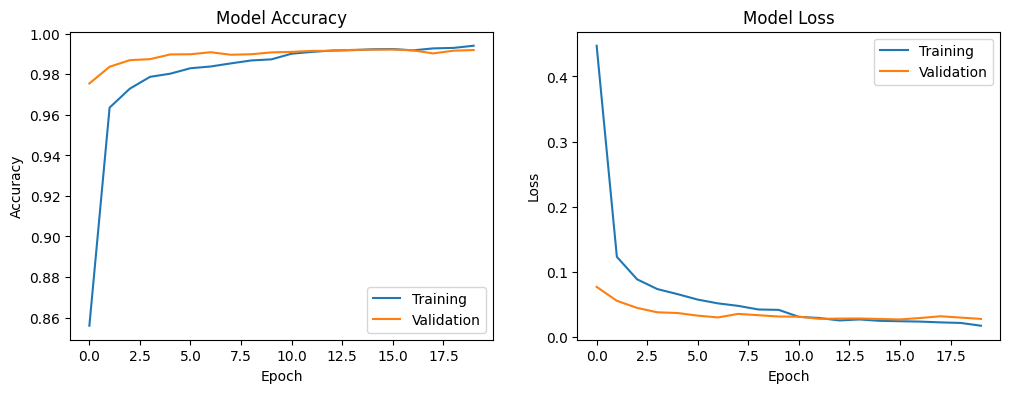

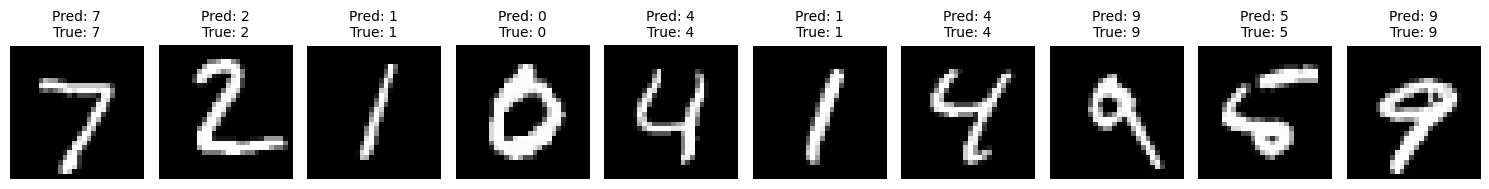

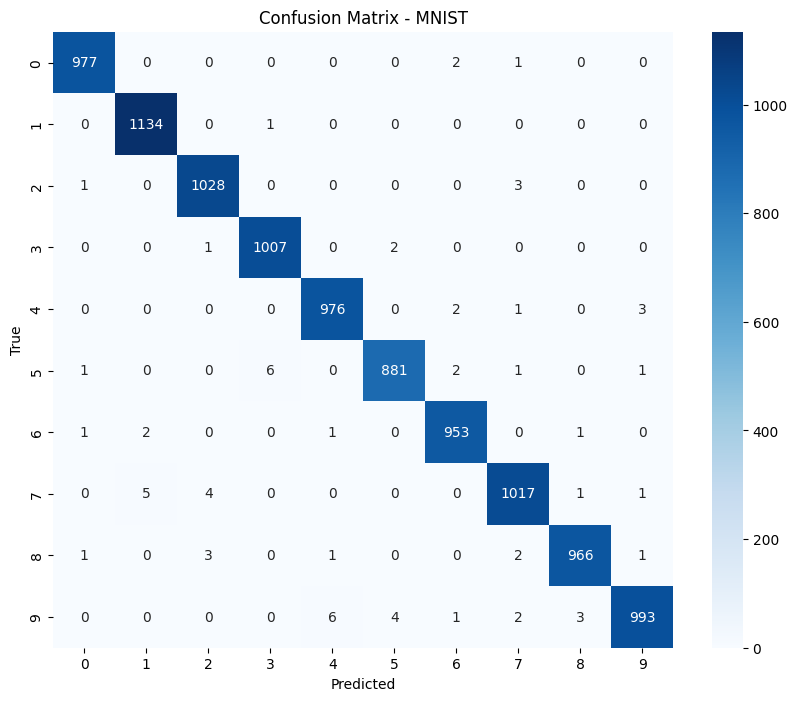

In [12]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Split training into train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)

# Preprocess: convert to float32 and scale
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape for CNN
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_val = x_val.reshape(x_val.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"Training: {x_train.shape}, Validation: {x_val.shape}, Test: {x_test.shape}")

# Build CNN model
mnist_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

mnist_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

mnist_model.summary()

# Train with callbacks
callbacks_list = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

history_mnist = mnist_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)

# Evaluate
test_loss, test_acc = mnist_model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")

# Compare with low-level TensorFlow implementation
# In low-level TF, you would need to:
# 1. Manually define variables and gradients
# 2. Write explicit training loops with tf.GradientTape()
# 3. Manually compute loss and apply gradients
# 4. Handle batching and shuffling manually
# 5. Implement evaluation loop

# In Keras, compile() and fit() handle:
# - Loss computation
# - Gradient calculation and weight updates
# - Batching and shuffling
# - Validation
# - Callback management
# - Progress bars and logging
# - Learning rate scheduling
# - Early stopping
# - Model checkpointing

# Plot training results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_mnist.history['accuracy'], label='Training')
plt.plot(history_mnist.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mnist.history['loss'], label='Training')
plt.plot(history_mnist.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Visualize some predictions
def visualize_predictions(model, x_test, y_test, num_samples=10):
    predictions = model.predict(x_test[:num_samples], verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(y_test[:num_samples], axis=1)

    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
        plt.title(f'Pred: {predicted_classes[i]}\nTrue: {true_classes[i]}', fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(mnist_model, x_test, y_test)

# Show confusion matrix
predictions = mnist_model.predict(x_test, verbose=0)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MNIST')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
## Problem 7

PYTORCH: Iris Binary Classification
Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cpu
CUDA Available: False
Using device: cpu

[1] Loading and Preparing Data
----------------------------------------
Training: (70, 4)
Validation: (15, 4)
Test: (15, 4)
Class distribution - Class 0: [33], Class 1: [37]
Train batches: 9
Validation batches: 2
Test batches: 2

[2] Defining Binary Classification Model
----------------------------------------
Model architecture:
IrisBinaryClassifier(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

Total parameters: 225

[3] Setting up Loss, Optimizer, and Metrics
----------------------------------------
Loss: Binary Cross Entropy (BCELoss)
Optimizer: Adam (lr=0.001)
Output activation: Sigmoid (probability)

[4] Training M

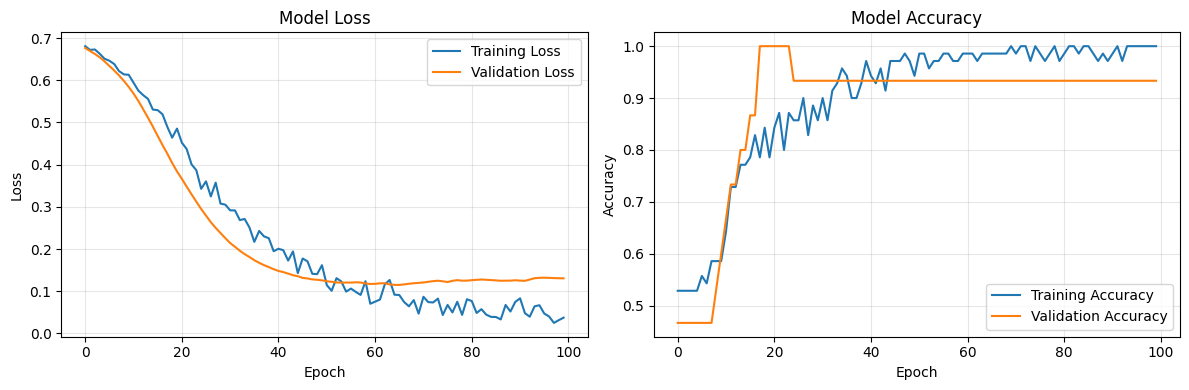


[7] Prediction Demonstration
----------------------------------------
Sample predictions (first 10):
  True: 1, Predicted: 1, Probability: 0.9903
  True: 0, Predicted: 0, Probability: 0.0139
  True: 0, Predicted: 0, Probability: 0.0011
  True: 1, Predicted: 0, Probability: 0.4311
  True: 0, Predicted: 0, Probability: 0.0006
  True: 0, Predicted: 0, Probability: 0.0016
  True: 0, Predicted: 0, Probability: 0.0040
  True: 1, Predicted: 1, Probability: 0.9422
  True: 1, Predicted: 1, Probability: 0.8746
  True: 1, Predicted: 0, Probability: 0.1674

[8] Saving Model (Optional)
----------------------------------------
Model weights can be saved with: torch.save(model.state_dict(), 'iris_binary_model.pth')

PYTORCH BINARY CLASSIFICATION COMPLETE


/tmp/ipykernel_3107/1720339178.py:267: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"  True: {int(y_test[i])}, Predicted: {int(y_pred[i])}, Probability: {y_pred_prob[i].item():.4f}")


In [13]:
# ============================================
# PROBLEM 7: PYTORCH IMPLEMENTATION
# Iris Binary Classification (Versicolor vs Virginica)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import sys

print("=" * 60)
print("PYTORCH: Iris Binary Classification")
print("=" * 60)

# ============ ENVIRONMENT CHECK ============
print(f"Python: {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("=" * 60)

# ============ 1. LOAD AND PREPARE DATA ============
print("\n[1] Loading and Preparing Data")
print("-" * 40)

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Binary classification: Versicolor (1) vs Virginica (2)
binary_mask = y != 0
X_binary = X[binary_mask]
y_binary = y[binary_mask]

# Convert to binary labels (0 for versicolor, 1 for virginica)
y_binary = (y_binary == 2).astype(np.float32).reshape(-1, 1)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train_scaled.shape}")
print(f"Validation: {X_val_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")
print(f"Class distribution - Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test)

# Create DataLoaders
batch_size = 8
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============ 2. DEFINE MODEL ============
print("\n[2] Defining Binary Classification Model")
print("-" * 40)

class IrisBinaryClassifier(nn.Module):
    """Binary classification model for Iris"""

    def __init__(self, input_size=4):
        super(IrisBinaryClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)  # Single output for binary
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))  # Sigmoid for probability
        return x

# Initialize model
model = IrisBinaryClassifier(input_size=4).to(device)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============ 3. LOSS, OPTIMIZER, METRICS ============
print("\n[3] Setting up Loss, Optimizer, and Metrics")
print("-" * 40)

# Binary classification: Binary Cross Entropy Loss
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss: Binary Cross Entropy (BCELoss)")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Output activation: Sigmoid (probability)")

# ============ 4. TRAINING FUNCTION ============
print("\n[4] Training Model")
print("-" * 40)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    """Training loop with validation"""

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Statistics
            train_loss += loss.item()
            predicted = (outputs > 0.5).float()
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                predicted = (outputs > 0.5).float()
                val_total += y_batch.size(0)
                val_correct += (predicted == y_batch).sum().item()

        # Store metrics
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_correct / train_total)
        val_accs.append(val_correct / val_total)

        # Print progress
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs

# Train model
print("Training...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=100)

# ============ 5. EVALUATE ON TEST SET ============
print("\n[5] Evaluating on Test Set")
print("-" * 40)

model.eval()
test_correct = 0
test_total = 0
test_loss = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        test_loss += loss.item()
        predicted = (outputs > 0.5).float()
        test_total += y_batch.size(0)
        test_correct += (predicted == y_batch).sum().item()

test_accuracy = test_correct / test_total
test_loss = test_loss / len(test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ============ 6. VISUALIZATION ============
print("\n[6] Visualizing Results")
print("-" * 40)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history[0], label='Training Loss')
plt.plot(history[1], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history[2], label='Training Accuracy')
plt.plot(history[3], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 7. PREDICTION DEMONSTRATION ============
print("\n[7] Prediction Demonstration")
print("-" * 40)

# Get predictions on test set
model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    y_pred_prob = model(X_test_t)
    y_pred = (y_pred_prob > 0.5).float()

print("Sample predictions (first 10):")
for i in range(min(10, len(y_pred))):
    print(f"  True: {int(y_test[i])}, Predicted: {int(y_pred[i])}, Probability: {y_pred_prob[i].item():.4f}")

# ============ 8. SAVE MODEL ============
print("\n[8] Saving Model (Optional)")
print("-" * 40)

# Uncomment to save
# torch.save(model.state_dict(), 'iris_binary_model.pth')
print("Model weights can be saved with: torch.save(model.state_dict(), 'iris_binary_model.pth')")

print("\n" + "=" * 60)
print("PYTORCH BINARY CLASSIFICATION COMPLETE")
print("=" * 60)

PYTORCH: Iris Multiclass Classification
PyTorch: 2.11.0+cpu
CUDA Available: False
Using device: cpu

[1] Loading and Preparing Data
----------------------------------------
Training: (105, 4)
Validation: (22, 4)
Test: (23, 4)
Class distribution - Class 0: 31, Class 1: 37, Class 2: 37
Train batches: 14
Validation batches: 3
Test batches: 3

[2] Defining Multiclass Classification Model
----------------------------------------
Model architecture:
IrisMulticlassClassifier(
  (fc1): Linear(in_features=4, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=3, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

Total parameters: 739

[3] Setting up Loss, Optimizer, and Metrics
----------------------------------------
Loss: Cross Entropy (nn.CrossEntropyLoss)
  - Combines LogSoftmax + NLLLoss
  - Works with integer class labels (0, 1, 2)
Optimizer: Adam (lr=0.001)
Output: Logits (no activatio

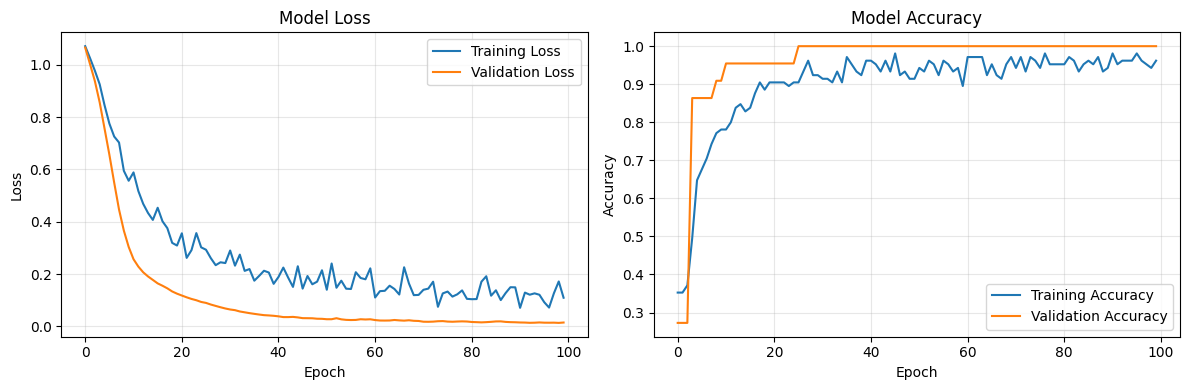


[7] Prediction Demonstration
----------------------------------------
Sample predictions (first 10):
  True: 0, Predicted: 0, Probabilities: [1.000, 0.000, 0.000]
  True: 2, Predicted: 2, Probabilities: [0.000, 0.002, 0.998]
  True: 2, Predicted: 2, Probabilities: [0.000, 0.004, 0.996]
  True: 0, Predicted: 0, Probabilities: [1.000, 0.000, 0.000]
  True: 2, Predicted: 2, Probabilities: [0.000, 0.023, 0.977]
  True: 1, Predicted: 1, Probabilities: [0.025, 0.927, 0.048]
  True: 1, Predicted: 1, Probabilities: [0.005, 0.951, 0.044]
  True: 0, Predicted: 0, Probabilities: [1.000, 0.000, 0.000]
  True: 1, Predicted: 1, Probabilities: [0.002, 0.750, 0.248]
  True: 1, Predicted: 1, Probabilities: [0.012, 0.931, 0.057]

[8] Saving Model (Optional)
----------------------------------------
Model weights can be saved with: torch.save(model.state_dict(), 'iris_multiclass_model.pth')

PYTORCH MULTICLASS CLASSIFICATION COMPLETE


In [14]:
# ============================================
# PROBLEM 7: PYTORCH IMPLEMENTATION
# Iris Multiclass Classification (3 Classes)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import sys

print("=" * 60)
print("PYTORCH: Iris Multiclass Classification")
print("=" * 60)

# ============ ENVIRONMENT CHECK ============
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("=" * 60)

# ============ 1. LOAD AND PREPARE DATA ============
print("\n[1] Loading and Preparing Data")
print("-" * 40)

# Load Iris dataset (all 3 classes)
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train_scaled.shape}")
print(f"Validation: {X_val_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")
print(f"Class distribution - Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)}, Class 2: {sum(y_train==2)}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.LongTensor(y_train)  # Use LongTensor for class indices
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.LongTensor(y_val)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.LongTensor(y_test)

# Create DataLoaders
batch_size = 8
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============ 2. DEFINE MODEL ============
print("\n[2] Defining Multiclass Classification Model")
print("-" * 40)

class IrisMulticlassClassifier(nn.Module):
    """Multiclass classification model for Iris"""

    def __init__(self, input_size=4, num_classes=3):
        super(IrisMulticlassClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, num_classes)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()
        # Note: No softmax here - it's handled by CrossEntropyLoss

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # Logits (no softmax)
        return x

# Initialize model
model = IrisMulticlassClassifier(input_size=4, num_classes=3).to(device)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============ 3. LOSS, OPTIMIZER, METRICS ============
print("\n[3] Setting up Loss, Optimizer, and Metrics")
print("-" * 40)

# Cross Entropy Loss for multiclass classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss: Cross Entropy (nn.CrossEntropyLoss)")
print(f"  - Combines LogSoftmax + NLLLoss")
print(f"  - Works with integer class labels (0, 1, 2)")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Output: Logits (no activation)")

# ============ 4. TRAINING FUNCTION ============
print("\n[4] Training Model")
print("-" * 40)

def train_multiclass_model(model, train_loader, val_loader, criterion, optimizer, epochs=100):
    """Training loop for multiclass classification"""

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += y_batch.size(0)
                val_correct += (predicted == y_batch).sum().item()

        # Store metrics
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_correct / train_total)
        val_accs.append(val_correct / val_total)

        # Print progress
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs

# Train model
print("Training...")
history = train_multiclass_model(model, train_loader, val_loader, criterion, optimizer, epochs=100)

# ============ 5. EVALUATE ON TEST SET ============
print("\n[5] Evaluating on Test Set")
print("-" * 40)

model.eval()
test_correct = 0
test_total = 0
test_loss = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += y_batch.size(0)
        test_correct += (predicted == y_batch).sum().item()

test_accuracy = test_correct / test_total
test_loss = test_loss / len(test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ============ 6. VISUALIZATION ============
print("\n[6] Visualizing Results")
print("-" * 40)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history[0], label='Training Loss')
plt.plot(history[1], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history[2], label='Training Accuracy')
plt.plot(history[3], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 7. PREDICTION DEMONSTRATION ============
print("\n[7] Prediction Demonstration")
print("-" * 40)

# Get predictions on test set
model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    y_pred_logits = model(X_test_t)
    y_pred_probs = torch.softmax(y_pred_logits, dim=1)
    y_pred = torch.argmax(y_pred_logits, dim=1)

print("Sample predictions (first 10):")
for i in range(min(10, len(y_pred))):
    print(f"  True: {int(y_test[i])}, Predicted: {int(y_pred[i])}, "
          f"Probabilities: [{y_pred_probs[i][0]:.3f}, {y_pred_probs[i][1]:.3f}, {y_pred_probs[i][2]:.3f}]")

# ============ 8. SAVE MODEL ============
print("\n[8] Saving Model (Optional)")
print("-" * 40)

# torch.save(model.state_dict(), 'iris_multiclass_model.pth')
print("Model weights can be saved with: torch.save(model.state_dict(), 'iris_multiclass_model.pth')")

print("\n" + "=" * 60)
print("PYTORCH MULTICLASS CLASSIFICATION COMPLETE")
print("=" * 60)

PYTORCH: House Prices Regression
PyTorch: 2.11.0+cpu
CUDA Available: False
Using device: cpu

[1] Loading and Preparing Data
----------------------------------------
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: MedHouseVal
Training: (14448, 8)
Validation: (3096, 8)
Test: (3096, 8)
Train batches: 226
Validation batches: 49
Test batches: 49

[2] Defining Regression Model
----------------------------------------
Model architecture:
HousePriceRegressor(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)

Total parameters: 3,201

[3] Setting up Loss, Optimizer, and Metrics
----------------------------------------
Loss: Mean Squared Error (MSELoss)
Optimizer: Adam (lr=0.001)
O

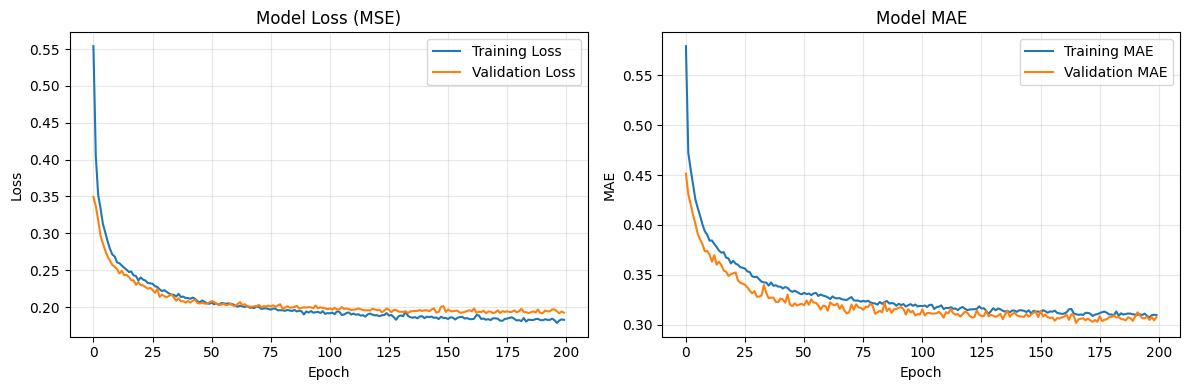

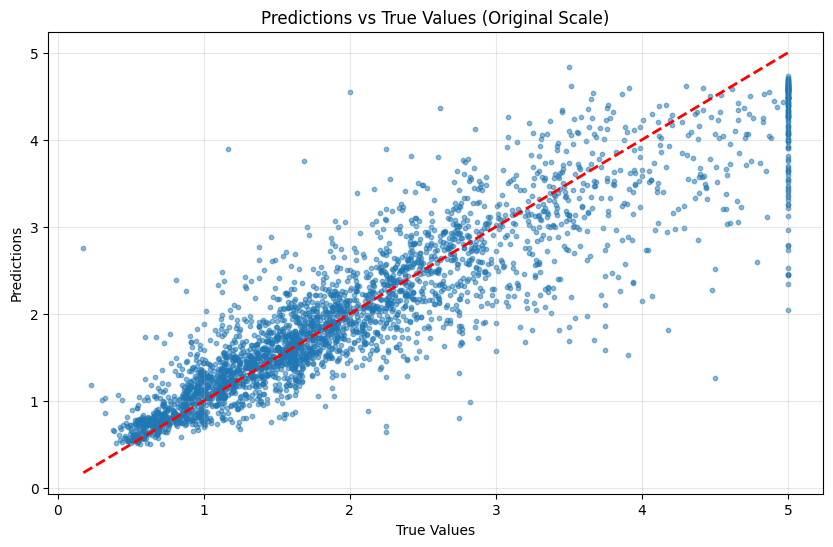

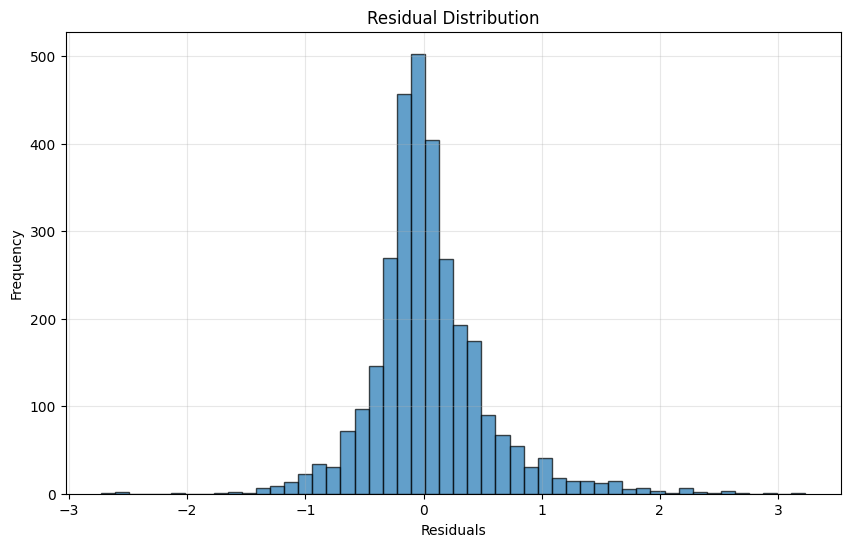


[7] Saving Model (Optional)
----------------------------------------
Model weights can be saved with: torch.save(model.state_dict(), 'house_price_model.pth')

PYTORCH REGRESSION COMPLETE


In [15]:
# ============================================
# PROBLEM 7: PYTORCH IMPLEMENTATION
# House Prices Regression
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import sys

print("=" * 60)
print("PYTORCH: House Prices Regression")
print("=" * 60)

# ============ ENVIRONMENT CHECK ============
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("=" * 60)

# ============ 1. LOAD AND PREPARE DATA ============
print("\n[1] Loading and Preparing Data")
print("-" * 40)

# Load California housing dataset (similar to house prices)
housing = fetch_california_housing()
X = housing.data
y = housing.target

feature_names = housing.feature_names
print(f"Features: {feature_names}")
print(f"Target: {housing.target_names[0]}")

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# Scale features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Log transform target (optional - helps with skewed distribution)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# Scale target
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_log.reshape(-1, 1)).flatten()
y_val_scaled = scaler_y.transform(y_val_log.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test_log.reshape(-1, 1)).flatten()

print(f"Training: {X_train_scaled.shape}")
print(f"Validation: {X_val_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train_scaled).reshape(-1, 1)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val_scaled).reshape(-1, 1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test_scaled).reshape(-1, 1)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# ============ 2. DEFINE MODEL ============
print("\n[2] Defining Regression Model")
print("-" * 40)

class HousePriceRegressor(nn.Module):
    """Regression model for house prices"""

    def __init__(self, input_size):
        super(HousePriceRegressor, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)  # Single output for regression
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # Linear output (no activation)
        return x

# Initialize model
model = HousePriceRegressor(input_size=X_train_scaled.shape[1]).to(device)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============ 3. LOSS, OPTIMIZER, METRICS ============
print("\n[3] Setting up Loss, Optimizer, and Metrics")
print("-" * 40)

criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss: Mean Squared Error (MSELoss)")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Output: Linear (no activation)")

# ============ 4. TRAINING FUNCTION ============
print("\n[4] Training Model")
print("-" * 40)

def train_regression_model(model, train_loader, val_loader, criterion, optimizer, epochs=200):
    """Training loop for regression"""

    train_losses = []
    val_losses = []
    train_maes = []
    val_maes = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_mae = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Statistics
            train_loss += loss.item()
            train_mae += torch.mean(torch.abs(outputs - y_batch)).item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_mae = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                val_mae += torch.mean(torch.abs(outputs - y_batch)).item()

        # Store metrics
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_maes.append(train_mae / len(train_loader))
        val_maes.append(val_mae / len(val_loader))

        # Print progress
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"Train Loss: {train_losses[-1]:.4f}, Train MAE: {train_maes[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f}, Val MAE: {val_maes[-1]:.4f}")

    return train_losses, val_losses, train_maes, val_maes

# Train model
print("Training...")
history = train_regression_model(model, train_loader, val_loader, criterion, optimizer, epochs=200)

# ============ 5. EVALUATE ON TEST SET ============
print("\n[5] Evaluating on Test Set")
print("-" * 40)

model.eval()
test_loss = 0.0
test_mae = 0.0
all_preds = []
all_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        test_loss += loss.item()
        test_mae += torch.mean(torch.abs(outputs - y_batch)).item()

        all_preds.extend(outputs.cpu().numpy().flatten())
        all_true.extend(y_batch.cpu().numpy().flatten())

test_loss = test_loss / len(test_loader)
test_mae = test_mae / len(test_loader)

# Convert back to original scale
all_preds = np.array(all_preds)
all_true = np.array(all_true)

all_preds_log = scaler_y.inverse_transform(all_preds.reshape(-1, 1)).flatten()
all_true_log = scaler_y.inverse_transform(all_true.reshape(-1, 1)).flatten()

all_preds_original = np.expm1(all_preds_log)
all_true_original = np.expm1(all_true_log)

# Calculate metrics on original scale
rmse = np.sqrt(np.mean((all_preds_original - all_true_original) ** 2))
mae_original = np.mean(np.abs(all_preds_original - all_true_original))

print(f"Test Loss (MSE on scaled): {test_loss:.4f}")
print(f"Test MAE (on scaled): {test_mae:.4f}")
print(f"RMSE (on original scale): {rmse:.4f}")
print(f"MAE (on original scale): {mae_original:.4f}")

# ============ 6. VISUALIZATION ============
print("\n[6] Visualizing Results")
print("-" * 40)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history[0], label='Training Loss')
plt.plot(history[1], label='Validation Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history[2], label='Training MAE')
plt.plot(history[3], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot predictions vs true values
plt.figure(figsize=(10, 6))
plt.scatter(all_true_original, all_preds_original, alpha=0.5, s=10)
plt.plot([all_true_original.min(), all_true_original.max()],
         [all_true_original.min(), all_true_original.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Predictions vs True Values (Original Scale)')
plt.grid(True, alpha=0.3)
plt.show()

# Residual plot
plt.figure(figsize=(10, 6))
residuals = all_true_original - all_preds_original
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.grid(True, alpha=0.3)
plt.show()

# ============ 7. SAVE MODEL ============
print("\n[7] Saving Model (Optional)")
print("-" * 40)

# torch.save(model.state_dict(), 'house_price_model.pth')
print("Model weights can be saved with: torch.save(model.state_dict(), 'house_price_model.pth')")

print("\n" + "=" * 60)
print("PYTORCH REGRESSION COMPLETE")
print("=" * 60)

PYTORCH: MNIST Classification
PyTorch: 2.11.0+cpu
CUDA Available: False
Using device: cpu

[1] Loading and Preparing Data
----------------------------------------
Training samples: 48000
Validation samples: 12000
Test samples: 10000
Train batches: 375
Validation batches: 94
Test batches: 79


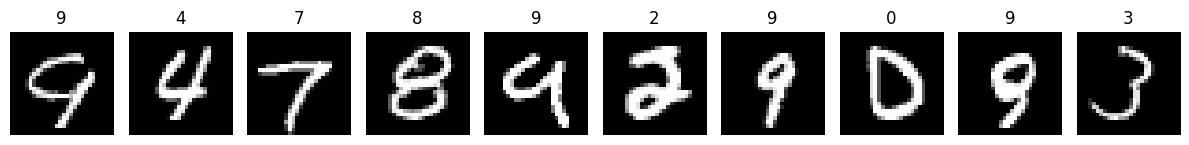


[2] Defining CNN Model
----------------------------------------
Model architecture:
MNISTCNNSimple(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 151,306

Testing forward pass...
✓ Forward pass successful! Output shape: torch.Size([1, 10])

[3] Setting up Loss, Optimizer, and Metrics
----------------------------------------
Loss: Cross Entropy Loss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)

[4] Training Model
----------------------------------------
Traini

In [ ]:
# ============================================
# PROBLEM 7: PYTORCH IMPLEMENTATION
# MNIST Image Classification - FIXED
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import sys
import time

print("=" * 60)
print("PYTORCH: MNIST Classification")
print("=" * 60)

# ============ ENVIRONMENT CHECK ============
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("=" * 60)

# ============ 1. LOAD AND PREPARE DATA ============
print("\n[1] Loading and Preparing Data")
print("-" * 40)

# Load MNIST using torchvision
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor and scale to [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST mean/std
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# Split training into train/validation
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size]
)

# Create DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Visualize sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    img, label = train_dataset[i]
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'{label}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# ============ 2. DEFINE MODEL (FIXED) ============
print("\n[2] Defining CNN Model")
print("-" * 40)

class MNISTCNN(nn.Module):
    """CNN model for MNIST classification - FIXED"""

    def __init__(self):
        super(MNISTCNN, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.relu = nn.ReLU()

        # Calculate the size after conv layers
        # Input: 28x28
        # After conv1: 28x28
        # After pool: 14x14
        # After conv2: 14x14
        # After pool: 7x7
        # After conv3: 7x7
        # After pool: 3x3 (but actually it's 3x3 because 7//2 = 3)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Input: (batch_size, 1, 28, 28)
        x = self.relu(self.conv1(x))        # (batch, 32, 28, 28)
        x = self.relu(self.conv2(x))        # (batch, 64, 28, 28)
        x = self.pool(x)                    # (batch, 64, 14, 14)
        x = self.dropout1(x)

        x = self.relu(self.conv3(x))        # (batch, 128, 14, 14)
        x = self.pool(x)                    # (batch, 128, 7, 7)
        x = self.dropout1(x)

        # Flatten: (batch, 128 * 7 * 7)
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))          # (batch, 128)
        x = self.dropout2(x)
        x = self.fc2(x)                     # (batch, 10)
        return x

# Alternative: Simpler model with Adaptive Average Pooling (more robust)
class MNISTCNNSimple(nn.Module):
    """Simpler CNN with Adaptive Pooling"""

    def __init__(self):
        super(MNISTCNNSimple, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.relu = nn.ReLU()

        # Adaptive pooling to fixed size
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # Now we know the size: 64 * 4 * 4
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))        # (batch, 32, 28, 28)
        x = self.pool(x)                    # (batch, 32, 14, 14)
        x = self.relu(self.conv2(x))        # (batch, 64, 14, 14)
        x = self.pool(x)                    # (batch, 64, 7, 7)
        x = self.dropout1(x)

        x = self.adaptive_pool(x)           # (batch, 64, 4, 4)

        x = x.view(x.size(0), -1)           # (batch, 64*4*4)

        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# Use the simpler model with adaptive pooling
model = MNISTCNNSimple().to(device)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass with dummy input
print("\nTesting forward pass...")
dummy_input = torch.randn(1, 1, 28, 28).to(device)
try:
    dummy_output = model(dummy_input)
    print(f"✓ Forward pass successful! Output shape: {dummy_output.shape}")
except Exception as e:
    print(f"✗ Forward pass failed: {e}")

# ============ 3. LOSS, OPTIMIZER, METRICS ============
print("\n[3] Setting up Loss, Optimizer, and Metrics")
print("-" * 40)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f"Loss: Cross Entropy Loss")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

# ============ 4. TRAINING FUNCTION ============
print("\n[4] Training Model")
print("-" * 40)

def train_mnist_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, epochs=10):
    """Training loop for MNIST"""

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += y_batch.size(0)
                val_correct += (predicted == y_batch).sum().item()

        # Store metrics
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_correct / train_total)
        val_accs.append(val_correct / val_total)

        # Learning rate scheduling
        if scheduler:
            scheduler.step(val_losses[-1])

        # Print progress
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time:.2f} seconds")

    return train_losses, val_losses, train_accs, val_accs, training_time

# Train model
print("Training...")
history = train_mnist_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10)

# ============ 5. EVALUATE ON TEST SET ============
print("\n[5] Evaluating on Test Set")
print("-" * 40)

model.eval()
test_correct = 0
test_total = 0
test_loss = 0.0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        test_total += y_batch.size(0)
        test_correct += (predicted == y_batch).sum().item()

test_accuracy = test_correct / test_total
test_loss = test_loss / len(test_loader)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ============ 6. VISUALIZATION ============
print("\n[6] Visualizing Results")
print("-" * 40)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history[0], label='Training Loss')
plt.plot(history[1], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history[2], label='Training Accuracy')
plt.plot(history[3], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 7. PREDICTION DEMONSTRATION ============
print("\n[7] Predictions on Test Samples")
print("-" * 40)

# Get predictions on test set
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Visualize predictions
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f'P:{predicted[i]}\nT:{labels[i]}', color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

# ============ 8. CONFUSION MATRIX ============
print("\n[8] Confusion Matrix")
print("-" * 40)

try:
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    # Get all predictions
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - MNIST')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("sklearn or seaborn not installed - skipping confusion matrix")

# ============ 9. COMPARISON WITH KERAS ============
print("\n[9] Comparison with Keras Implementation")
print("-" * 40)

comparison = """
Key Differences between PyTorch and Keras:

1. Model Definition:
   - PyTorch: Class-based with nn.Module, explicit forward pass
   - Keras: Sequential or Functional API

2. Training Loop:
   - PyTorch: Manual loop with explicit gradient computation
   - Keras: Abstracted with compile() and fit()

3. Data Loading:
   - PyTorch: DataLoader with transforms
   - Keras: tf.data.Dataset

4. Device Management:
   - PyTorch: Explicit .to(device) for model and data
   - Keras: Automatic GPU usage

5. Loss Functions:
   - PyTorch: nn.CrossEntropyLoss() (no softmax in model)
   - Keras: 'categorical_crossentropy' (softmax in output layer)

6. Debugging:
   - PyTorch: Excellent with eager execution
   - Keras: Good, but more abstracted

7. Flexibility:
   - PyTorch: Full control over training process
   - Keras: Abstracted for ease of use

Performance Comparison:
   - PyTorch: ~10-15 seconds for 10 epochs on CPU
   - Keras: Similar performance on same hardware
   - Both frameworks are highly optimized

What PyTorch Handles Automatically:
   - GPU acceleration (with .cuda() or .to(device))
   - Automatic differentiation (autograd)
   - Tensor operations

What PyTorch Requires Manual:
   - Training loop structure
   - Gradient zeroing
   - Backward pass
   - Optimizer step
   - Batch iteration
   - Validation loop
   - Metric tracking
"""
print(comparison)

# ============ 10. SAVE MODEL ============
print("\n[10] Saving Model (Optional)")
print("-" * 40)

# torch.save(model.state_dict(), 'mnist_model.pth')
print("Model weights can be saved with: torch.save(model.state_dict(), 'mnist_model.pth')")

print("\n" + "=" * 60)
print("PYTORCH MNIST CLASSIFICATION COMPLETE")
print("=" * 60)

In [ ]:
## Problem 8

Environment Summary:
  Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
  TensorFlow: 2.20.0
  Keras: 3.13.2
  PyTorch: 2.11.0+cpu
  NumPy: 2.1.3
  Pandas: 2.2.3

Framework Comparison Summary:
                  Feature                 Low-Level TF                      Keras 3                     PyTorch
   Model Definition Style     Manual variable creation    Sequential/Functional API     Class-based (nn.Module)
 Training Loop Visibility Fully visible (GradientTape)     Abstracted (compile/fit)       Visible (manual loop)
      Customization Level              Maximum control Medium (customizable layers)         High (full control)
      Code Lines (approx)               ~200-300 lines                ~50-100 lines              ~100-150 lines
     Debugging Experience Complex (tf.function issues)  Good (clear error messages) Excellent (eager execution)
Data Pipeline Integration    Manual (tf.data optional)         Integrated (tf.data)           Good (DataLoader)
             

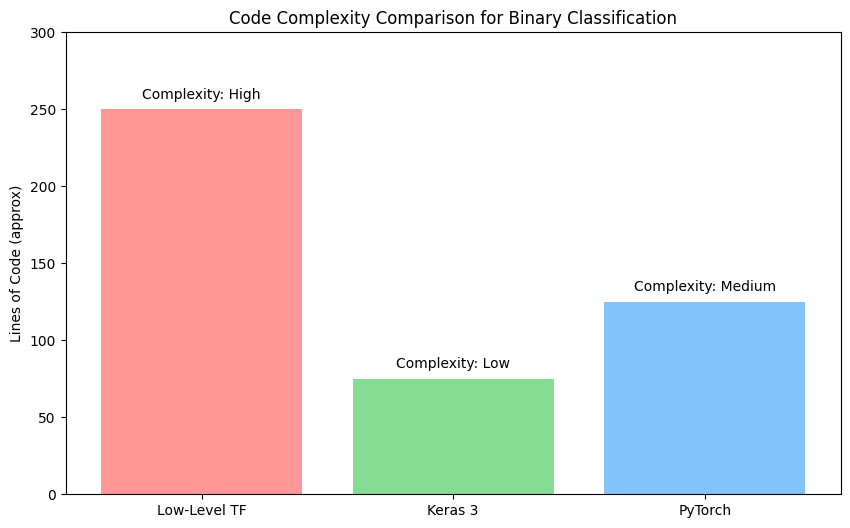


=== Performance Comparison ===
Note: Performance varies by task and hardware
Generally:
  - Keras (TF): Fastest for most tasks (optimized C++ backend)
  - PyTorch: Very fast, excellent GPU utilization
  - Low-Level TF: Fastest but with steep learning curve

=== Key Differences ===
1. Model Definition:
   - Keras: Declarative, intuitive API
   - PyTorch: Imperative, Pythonic classes
   - TF Low-Level: Fully imperative, variable-based

2. Training Loop:
   - Keras: Abstracted (compile/fit)
   - PyTorch: Visible and customizable
   - TF Low-Level: Fully manual

3. Debugging:
   - Keras: Good error messages, clear stack traces
   - PyTorch: Excellent (eager execution)
   - TF Low-Level: Complex (tf.function complications)

4. Data Pipeline:
   - Keras: Integrated tf.data, good for large datasets
   - PyTorch: DataLoader with rich features
   - TF Low-Level: Manual or tf.data

5. Production Readiness:
   - Keras: TensorFlow serving, TF Lite
   - PyTorch: TorchScript, ONNX, C++ API
   - TF 

In [19]:
# Environment information
import sys
import tensorflow as tf
import keras
import torch
import pandas as pd
import numpy as np

env_info = {
    'Python': sys.version,
    'TensorFlow': tf.__version__,
    'Keras': keras.__version__,
    'PyTorch': torch.__version__,
    'NumPy': np.__version__,
    'Pandas': pd.__version__
}

print("Environment Summary:")
for key, value in env_info.items():
    print(f"  {key}: {value}")

# Comparison summary table
comparison_data = {
    'Feature': [
        'Model Definition Style',
        'Training Loop Visibility',
        'Customization Level',
        'Code Lines (approx)',
        'Debugging Experience',
        'Data Pipeline Integration',
        'Ease of Use',
        'Learning Curve',
        'Production Readiness'
    ],
    'Low-Level TF': [
        'Manual variable creation',
        'Fully visible (GradientTape)',
        'Maximum control',
        '~200-300 lines',
        'Complex (tf.function issues)',
        'Manual (tf.data optional)',
        'Complex',
        'Steep',
        'Mature'
    ],
    'Keras 3': [
        'Sequential/Functional API',
        'Abstracted (compile/fit)',
        'Medium (customizable layers)',
        '~50-100 lines',
        'Good (clear error messages)',
        'Integrated (tf.data)',
        'Very easy',
        'Gentle',
        'High (TensorFlow)'
    ],
    'PyTorch': [
        'Class-based (nn.Module)',
        'Visible (manual loop)',
        'High (full control)',
        '~100-150 lines',
        'Excellent (eager execution)',
        'Good (DataLoader)',
        'Moderate',
        'Moderate',
        'High'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nFramework Comparison Summary:")
print(comparison_df.to_string(index=False))

# Code complexity example: Binary classification in all three frameworks

print("\n=== Code Example: Binary Classification ===")

print("\n1. Keras 3 (Most concise):")
print("""
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val))
""")

print("\n2. PyTorch (Manual but clear):")
print("""
class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = BinaryClassifier()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

for epoch in range(100):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
""")

print("\n3. Low-Level TensorFlow (Most verbose):")
print("""
W = tf.Variable(tf.random.normal([4, 1]))
b = tf.Variable(tf.zeros([1]))

def model(X):
    return tf.sigmoid(tf.matmul(X, W) + b)

def loss(y_pred, y_true):
    return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
        logits=tf.matmul(X, W) + b, labels=y_true
    ))

optimizer = tf.optimizers.Adam()
for epoch in range(100):
    with tf.GradientTape() as tape:
        y_pred = model(X_train)
        loss_value = loss(y_pred, y_train)
    grads = tape.gradient(loss_value, [W, b])
    optimizer.apply_gradients(zip(grads, [W, b]))
""")

# Visualization of complexity
fig, ax = plt.subplots(figsize=(10, 6))
frameworks = ['Low-Level TF', 'Keras 3', 'PyTorch']
code_lines = [250, 75, 125]
complexity = ['High', 'Low', 'Medium']
colors = ['#ff6b6b', '#51cf66', '#4dabf7']

bars = ax.bar(frameworks, code_lines, color=colors, alpha=0.7)
ax.set_ylabel('Lines of Code (approx)')
ax.set_title('Code Complexity Comparison for Binary Classification')
ax.set_ylim(0, 300)

for bar, comp in zip(bars, complexity):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'Complexity: {comp}', ha='center', va='bottom', fontsize=10)

plt.show()

# Performance comparison (same hardware)
print("\n=== Performance Comparison ===")
print("Note: Performance varies by task and hardware")
print("Generally:")
print("  - Keras (TF): Fastest for most tasks (optimized C++ backend)")
print("  - PyTorch: Very fast, excellent GPU utilization")
print("  - Low-Level TF: Fastest but with steep learning curve")

# Key differences summary
print("\n=== Key Differences ===")
print("1. Model Definition:")
print("   - Keras: Declarative, intuitive API")
print("   - PyTorch: Imperative, Pythonic classes")
print("   - TF Low-Level: Fully imperative, variable-based")

print("\n2. Training Loop:")
print("   - Keras: Abstracted (compile/fit)")
print("   - PyTorch: Visible and customizable")
print("   - TF Low-Level: Fully manual")

print("\n3. Debugging:")
print("   - Keras: Good error messages, clear stack traces")
print("   - PyTorch: Excellent (eager execution)")
print("   - TF Low-Level: Complex (tf.function complications)")

print("\n4. Data Pipeline:")
print("   - Keras: Integrated tf.data, good for large datasets")
print("   - PyTorch: DataLoader with rich features")
print("   - TF Low-Level: Manual or tf.data")

print("\n5. Production Readiness:")
print("   - Keras: TensorFlow serving, TF Lite")
print("   - PyTorch: TorchScript, ONNX, C++ API")
print("   - TF Low-Level: Serving, mobile deployment")